In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"estebanmorenoroa","key":"981356526472e247c28c737fdf8b815f"}'}

SANTIAGO AGUDELO:transformaciones

In [ ]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch import nn
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# Transformaciones
transform2 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

TRANSFORMACIONES

Resize

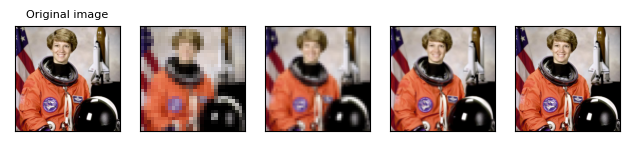

Grayscale

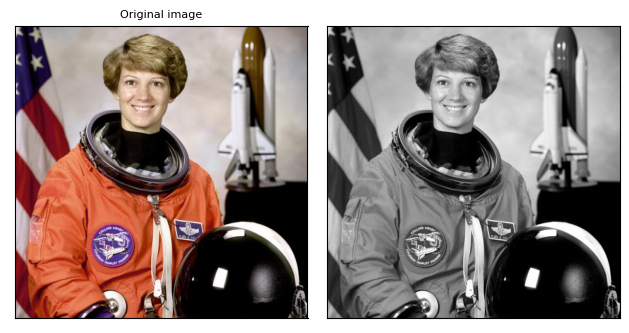

RandomHorizontalFlip

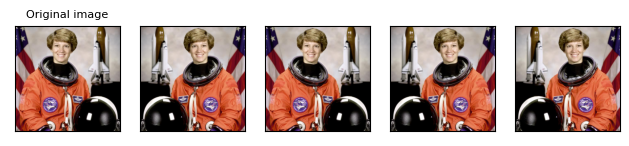

RandomRotation(15 GRADOS EN SENTIDO HORARIO O ANTIHORARIO)

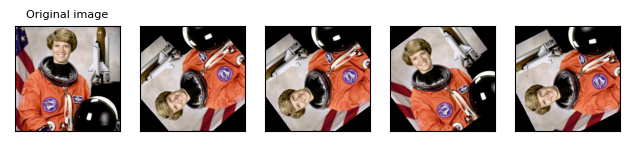

RESIZE DE 64X64
Precisión final en test:75%
BATCH = 256

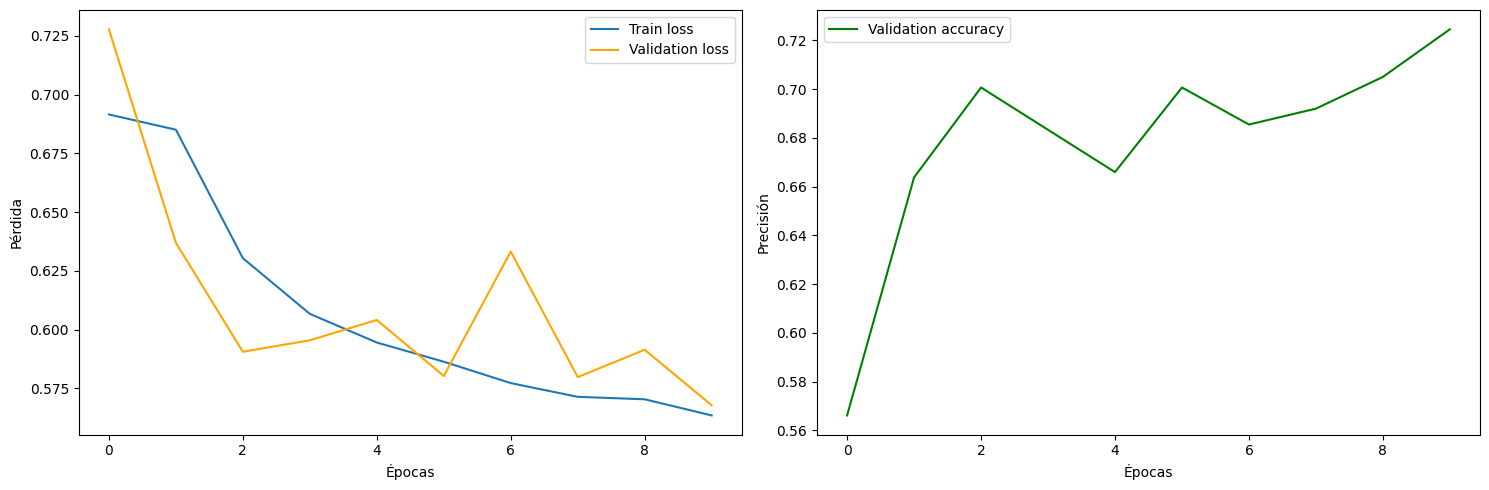

RESIZE 32X32 Precisión final en test: %75 BATCH=256

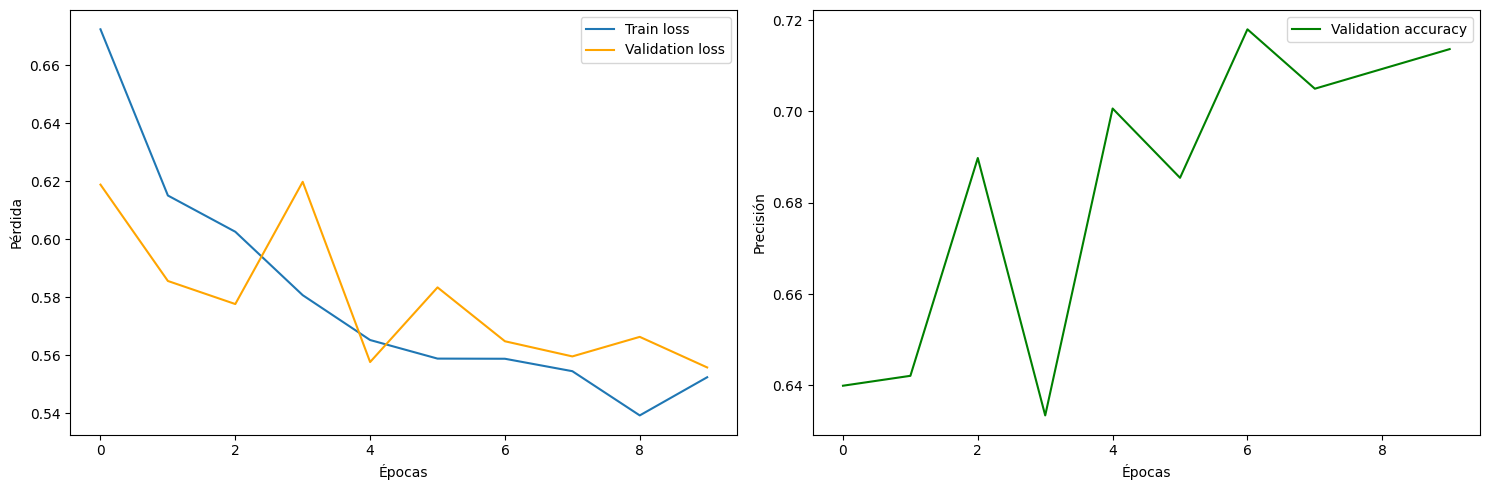

SOLO RESIZE, NORMALIZE, TO TENSOR Precisión final en test: 85% BATCH=256

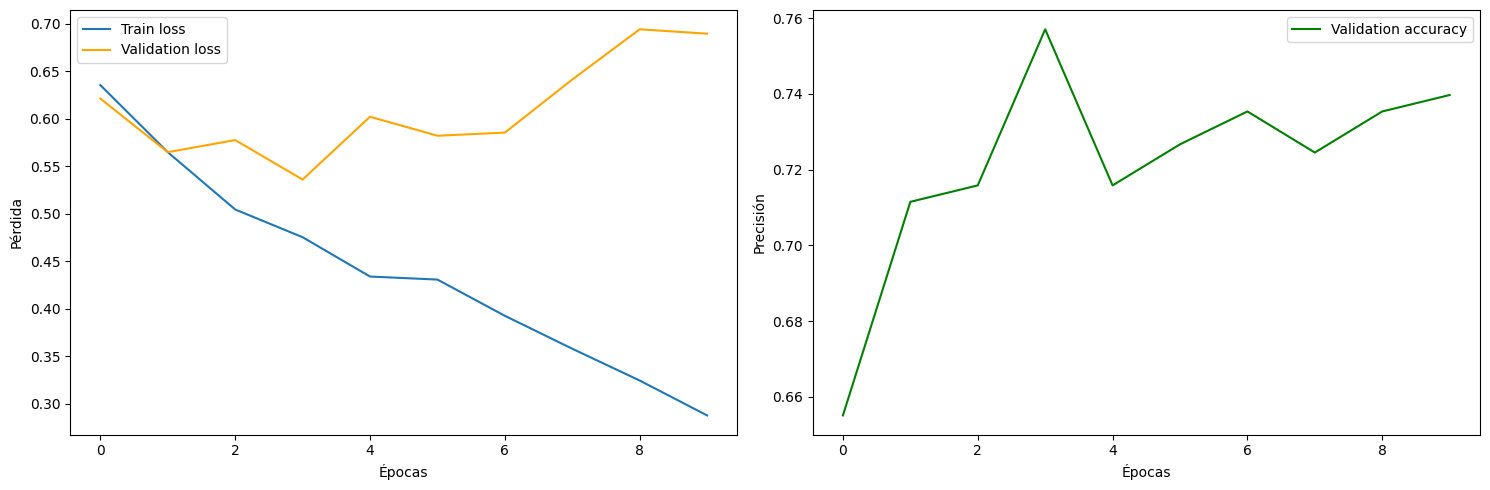

LADY VIDAL: hiperparametros

In [ ]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torch import nn
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from google.colab import drive
import time

drive.mount('/content/drive')

# Transformaciones
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Rutas de datos
train_root = "/content/drive/MyDrive/birdvsbutterfly/train"
test_root = "/content/drive/MyDrive/birdvsbutterfly/test"

# Hiperparámetros
batch_size = 512
hidden_layer = 256
hidden_layer1 = 128
hidden_layer2 = 64
input_layer = 64*64
output_size = 2

# Cargar y dividir datos
traindata = ImageFolder(root=train_root, transform=transform_train)
testdata = ImageFolder(root=test_root, transform=transform_test)

# sacar los datos de validacion
train_size = int(0.8 * len(traindata))
val_size = len(traindata) - train_size
train_dataset, val_dataset = random_split(traindata, [train_size, val_size])

# DataLoaders
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
testloader = DataLoader(testdata, batch_size=batch_size, shuffle=False)  # Se mantiene para evaluación final



BATCH SIZE=512 Precisión final en test: 64%

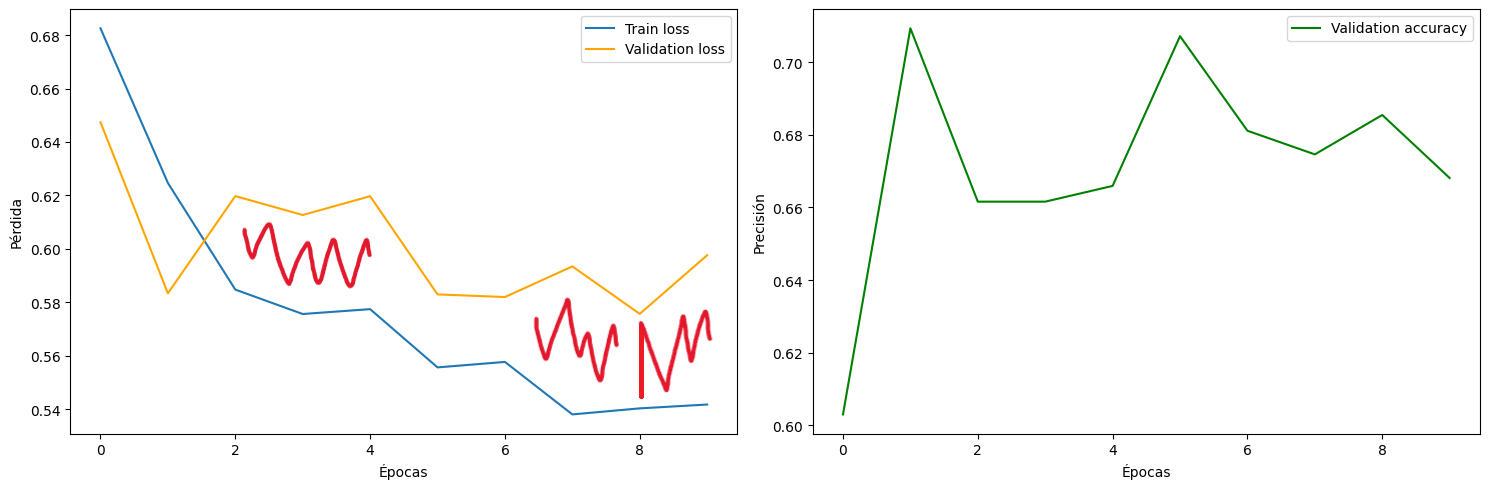

BATCH=16 Precisión final en test: 75%

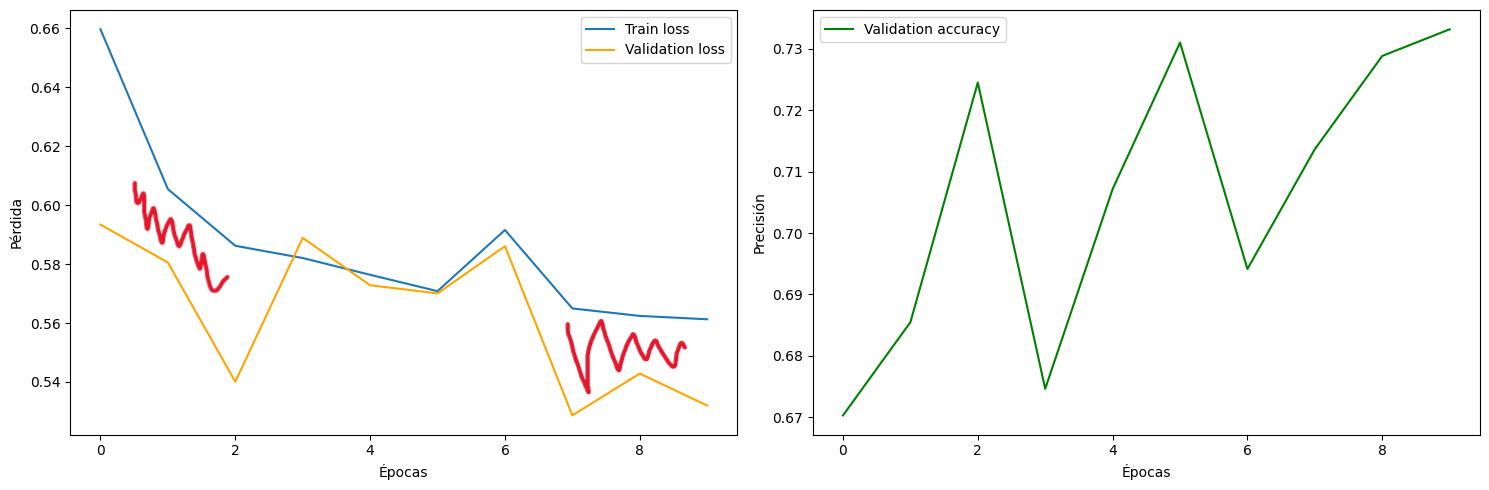

BATCH=64 Precisión final en test: 74%

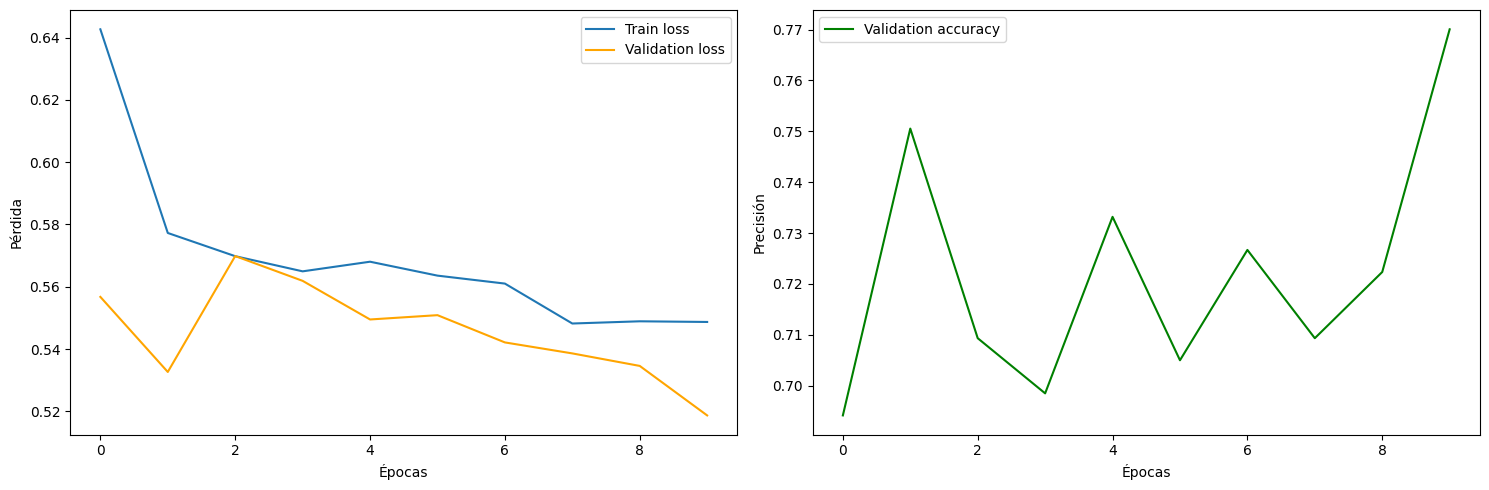

BATCH=64 Precisión final en test: 75%
QUITAMOS UNA CAPA CON EL FIN DE VER SU VARIABILIDAD



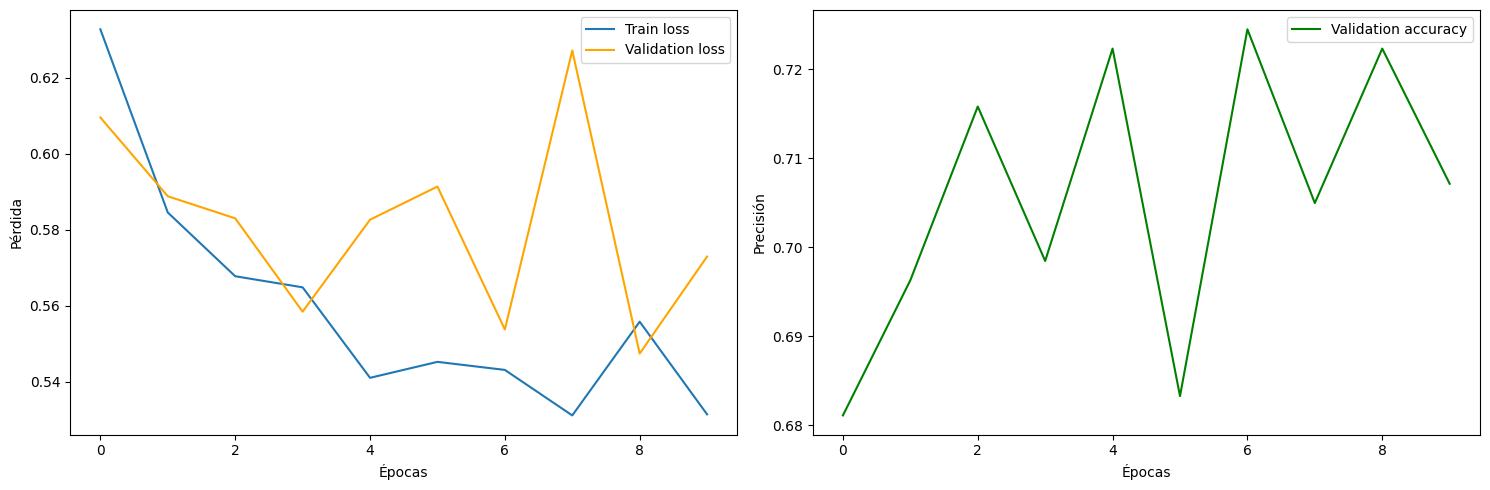

JUAN DAVID: entrenamiento y validacion

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Época 1/50.. Train loss: 0.681.. Val loss: 0.631.. Val accuracy: 0.633
Época 2/50.. Train loss: 0.629.. Val loss: 0.625.. Val accuracy: 0.623
Época 3/50.. Train loss: 0.599.. Val loss: 0.596.. Val accuracy: 0.659
Época 4/50.. Train loss: 0.569.. Val loss: 0.591.. Val accuracy: 0.683
Época 5/50.. Train loss: 0.560.. Val loss: 0.582.. Val accuracy: 0.675
Época 6/50.. Train loss: 0.554.. Val loss: 0.566.. Val accuracy: 0.692
Época 7/50.. Train loss: 0.553.. Val loss: 0.553.. Val accuracy: 0.679
Época 8/50.. Train loss: 0.546.. Val loss: 0.547.. Val accuracy: 0.709
Época 9/50.. Train loss: 0.531.. Val loss: 0.566.. Val accuracy: 0.709
Época 10/50.. Train loss: 0.545.. Val loss: 0.539.. Val accuracy: 0.701
Época 11/50.. Train loss: 0.527.. Val loss: 0.557.. Val accuracy: 0.688
Época 12/50.. Train loss: 0.530.. Val loss: 0.539.. Val accuracy: 0.705
Época 13/50.. Tr

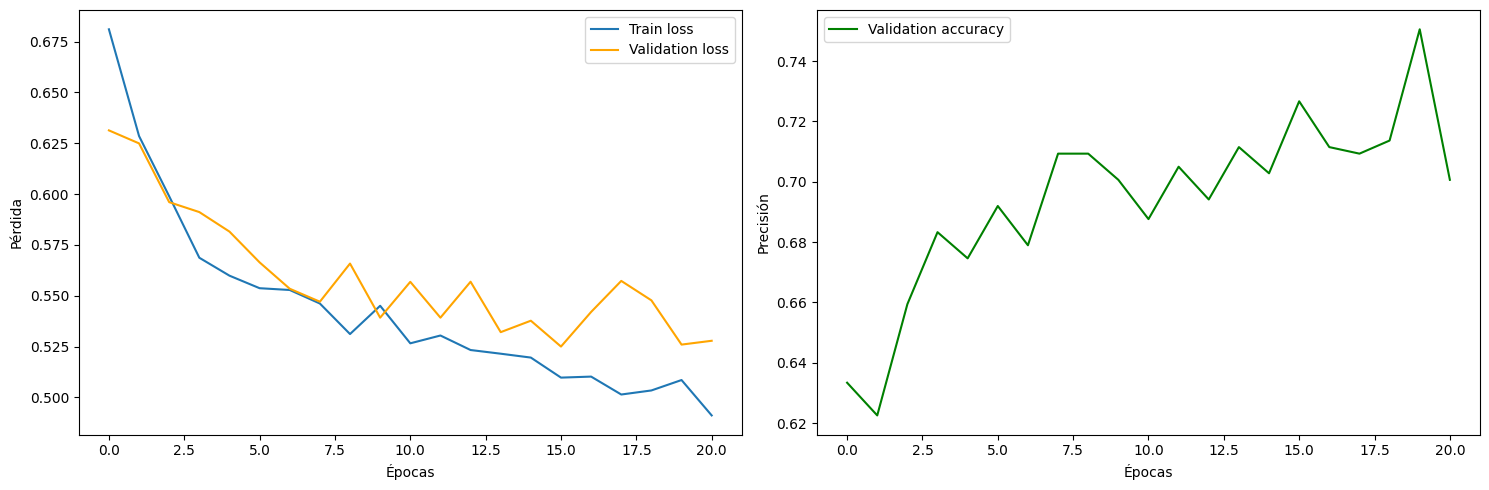


Tiempo total de entrenamiento: 607.08 segundos


In [ ]:


import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torch import nn
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from google.colab import drive
import time

drive.mount('/content/drive')

# Transformaciones
transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Rutas de datos
train_root = "/content/drive/MyDrive/birdvsbutterfly/train"
test_root = "/content/drive/MyDrive/birdvsbutterfly/test"

# Hiperparámetros
batch_size = 512
hidden_layer = 256
hidden_layer1 = 128
hidden_layer2 = 64
input_layer = 1024
output_size = 2

# Cargar y dividir datos
traindata = ImageFolder(root=train_root, transform=transform_train)
testdata = ImageFolder(root=test_root, transform=transform_test)

# Dividir entrenamiento (80% train, 20% validation)
train_size = int(0.8 * len(traindata))
val_size = len(traindata) - train_size
train_dataset, val_dataset = random_split(traindata, [train_size, val_size])

# DataLoaders
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
testloader = DataLoader(testdata, batch_size=batch_size, shuffle=False)  # Se mantiene para evaluación final

# Modelo
class ClassifierV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(input_layer, hidden_layer)
        self.fc2 = nn.Linear(hidden_layer, hidden_layer1)
        self.fc3 = nn.Linear(hidden_layer1, hidden_layer2)
        self.fc4 = nn.Linear(hidden_layer2, output_size)



    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

model = ClassifierV2()
criterion = nn.CrossEntropyLoss(reduction='sum')
optimizer = optim.Adam(model.parameters(), lr=0.003)
epochs = 50

# Listas para métricas
train_losses, val_losses, val_accuracies = [], [], []

start_time = time.time()
best_val_loss = float('inf')
patience = 5
trigger = 0

for e in range(epochs):
    # Entrenamiento
    model.train()
    tot_train_loss = 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        log_ps = model(images)
        loss = criterion(log_ps, labels)
        tot_train_loss += loss.item()
        loss.backward()
        optimizer.step()

    # Validación
    model.eval()
    tot_val_loss = 0
    val_correct = 0
    with torch.no_grad():
        for images, labels in valloader:
            log_ps = model(images)
            loss = criterion(log_ps, labels)
            tot_val_loss += loss.item()

            ps = torch.exp(log_ps)
            _, preds = ps.topk(1, dim=1)
            val_correct += (preds == labels.view(*preds.shape)).sum().item()

    # Calcular métricas
    train_loss = tot_train_loss / len(trainloader.dataset)
    val_loss = tot_val_loss / len(valloader.dataset)
    val_accuracy = val_correct / len(valloader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Época {e+1}/{epochs}.. "
          f"Train loss: {train_loss:.3f}.. "
          f"Val loss: {val_loss:.3f}.. "
          f"Val accuracy: {val_accuracy:.3f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            print("Early stopping activado.")
            break



# Evaluación FINAL
model.eval()
test_correct = 0
with torch.no_grad():
    for images, labels in testloader:
        log_ps = model(images)
        ps = torch.exp(log_ps)
        _, preds = ps.topk(1, dim=1)
        test_correct += (preds == labels.view(*preds.shape)).sum().item()

test_accuracy = test_correct / len(testloader.dataset)
print(f"\nPrecisión final en test: {test_accuracy:.3f}")

# Gráficos actualizados
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Validation loss', color='orange')
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Pérdida')

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation accuracy', color='green')

plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Precisión')

plt.tight_layout()
plt.show()

print(f"\nTiempo total de entrenamiento: {time.time() - start_time:.2f} segundos")

BATCH=64 Precisión final en test: 74%

1er ENTRENAMIENTO

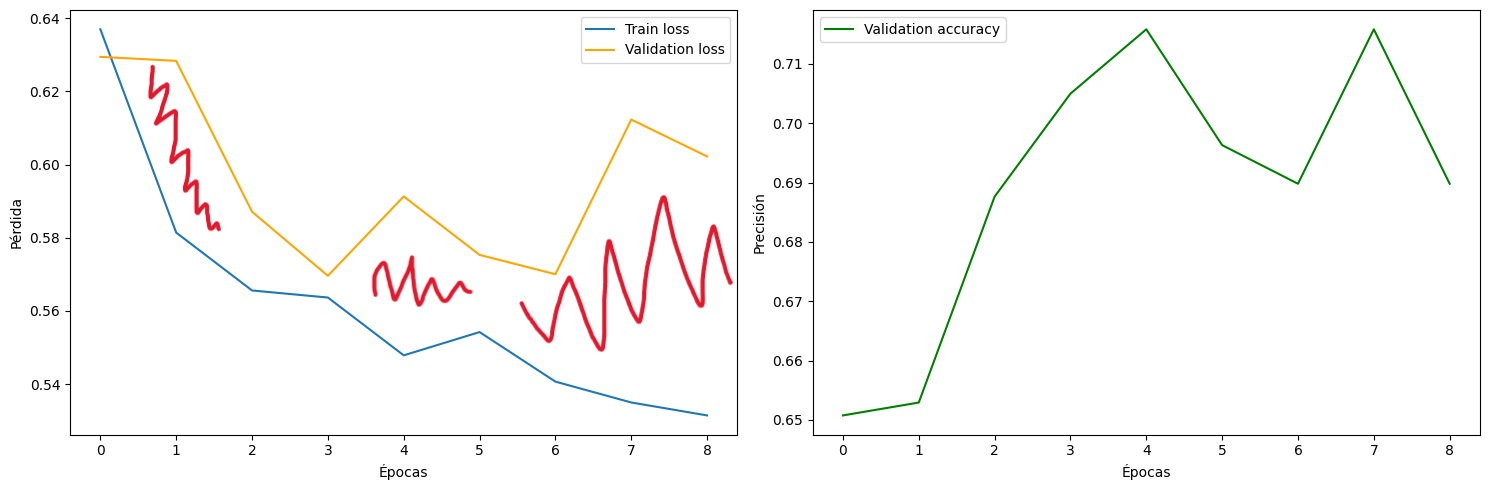

2do ENTRENAMIENTO BATCH=512 LR=0.003 COMO EN EL REPOSITORIO
SIN DATA AUGMENTATION Precisión final en test: 0.780

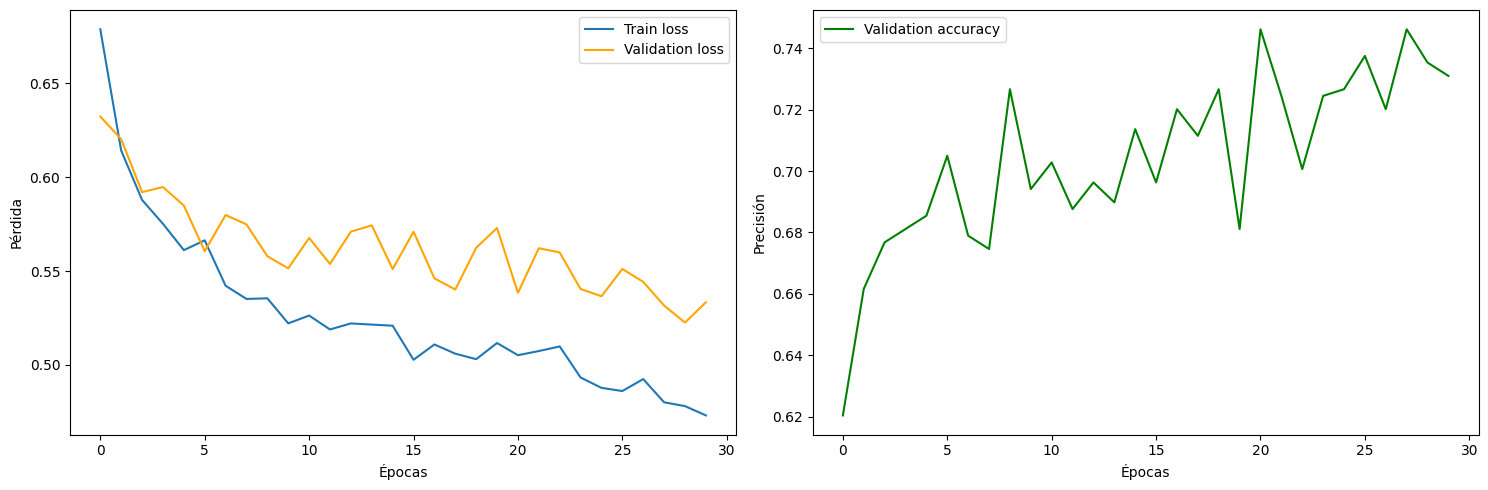



SANTIAGO MONTENEGRO DROPOUT

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Época 1/50.. Train loss: 0.692.. Val loss: 0.680.. Val accuracy: 0.544
Época 2/50.. Train loss: 0.649.. Val loss: 0.665.. Val accuracy: 0.616
Época 3/50.. Train loss: 0.620.. Val loss: 0.629.. Val accuracy: 0.662
Época 4/50.. Train loss: 0.615.. Val loss: 0.636.. Val accuracy: 0.633
Época 5/50.. Train loss: 0.594.. Val loss: 0.587.. Val accuracy: 0.716
Época 6/50.. Train loss: 0.576.. Val loss: 0.603.. Val accuracy: 0.675
Época 7/50.. Train loss: 0.571.. Val loss: 0.574.. Val accuracy: 0.733
Época 8/50.. Train loss: 0.561.. Val loss: 0.561.. Val accuracy: 0.731
Época 9/50.. Train loss: 0.549.. Val loss: 0.573.. Val accuracy: 0.705
Época 10/50.. Train loss: 0.545.. Val loss: 0.552.. Val accuracy: 0.725
Época 11/50.. Train loss: 0.545.. Val loss: 0.555.. Val accuracy: 0.725
Época 12/50.. Train loss: 0.542.. Val loss: 0.547.. Val accuracy: 0.733
Época 13/50.. Tr

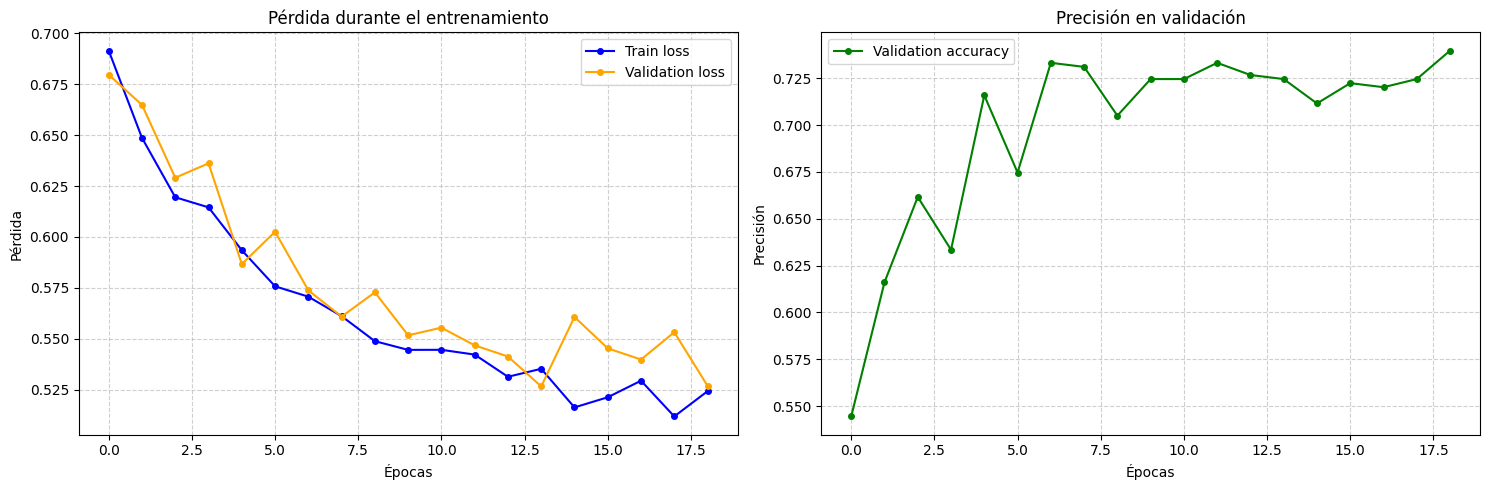


Tiempo total de entrenamiento: 485.01 segundos


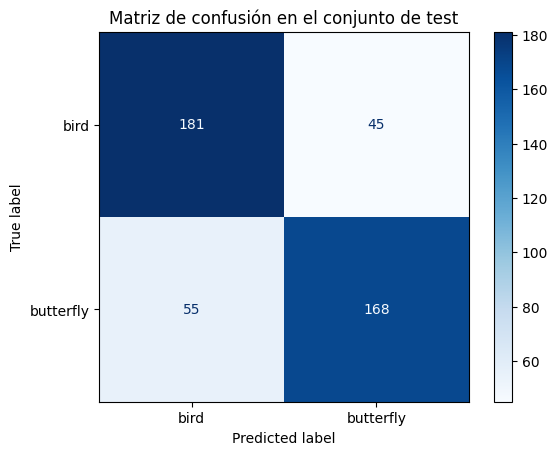

In [ ]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torch import nn
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from google.colab import drive
import time

# Montar Google Drive
drive.mount('/content/drive')

# Transformaciones para entrenamiento
transform_train = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Transformación para validación y test
transform_test = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Rutas
train_root = "/content/drive/MyDrive/birdvsbutterfly/train"
test_root = "/content/drive/MyDrive/birdvsbutterfly/test"

# Hiperparámetros
batch_size = 512
input_layer = 28*28
output_size = 2
epochs = 50
learning_rate = 0.003

# Carga y división de datos
traindata = ImageFolder(root=train_root, transform=transform_train)
testdata = ImageFolder(root=test_root, transform=transform_test)

train_size = int(0.8 * len(traindata))
val_size = len(traindata) - train_size
train_dataset, val_dataset = random_split(traindata, [train_size, val_size])

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
testloader = DataLoader(testdata, batch_size=batch_size, shuffle=False)

# Modelo con dropout
class ClassifierFinal(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(input_layer, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, output_size)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.dropout(F.relu(self.fc3(x)))
        x = F.log_softmax(self.fc4(x), dim=1)
        return x

# Inicializar modelo
model = ClassifierFinal()
criterion = nn.CrossEntropyLoss(reduction='sum')
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

# Entrenamiento con early stopping
train_losses, val_losses, val_accuracies = [], [], []
best_val_loss = float('inf')
patience = 5
trigger = 0

start_time = time.time()

for e in range(epochs):
    model.train()
    tot_train_loss = 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        log_ps = model(images)
        loss = criterion(log_ps, labels)
        tot_train_loss += loss.item()
        loss.backward()
        optimizer.step()

    model.eval()
    tot_val_loss = 0
    val_correct = 0
    with torch.no_grad():
        for images, labels in valloader:
            log_ps = model(images)
            loss = criterion(log_ps, labels)
            tot_val_loss += loss.item()
            ps = torch.exp(log_ps)
            _, preds = ps.topk(1, dim=1)
            val_correct += (preds == labels.view(*preds.shape)).sum().item()

    train_loss = tot_train_loss / len(trainloader.dataset)
    val_loss = tot_val_loss / len(valloader.dataset)
    val_accuracy = val_correct / len(valloader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Época {e+1}/{epochs}.. "
          f"Train loss: {train_loss:.3f}.. "
          f"Val loss: {val_loss:.3f}.. "
          f"Val accuracy: {val_accuracy:.3f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            print("Early stopping activado.")
            break

# Evaluación final en test
model.eval()
test_correct = 0
with torch.no_grad():
    for images, labels in testloader:
        log_ps = model(images)
        ps = torch.exp(log_ps)
        _, preds = ps.topk(1, dim=1)
        test_correct += (preds == labels.view(*preds.shape)).sum().item()

test_accuracy = test_correct / len(testloader.dataset)
print(f"\n Precisión final en test: {test_accuracy:.3f}")



print(f"\nTiempo total de entrenamiento: {time.time() - start_time:.2f} segundos")

# Gráficas con puntos y cuadrícula
plt.figure(figsize=(15, 5))

# Pérdida
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'o-', label='Train loss', color='blue', markersize=4)
plt.plot(val_losses, 'o-', label='Validation loss', color='orange', markersize=4)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Pérdida durante el entrenamiento')

# Precisión
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, 'o-', label='Validation accuracy', color='green', markersize=4)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.title('Precisión en validación')

plt.tight_layout()
plt.show()

print(f"\nTiempo total de entrenamiento: {time.time() - start_time:.2f} segundos")


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matriz de confusión
def plot_conf_matrix(model, dataloader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            log_ps = model(images)
            _, preds = torch.max(log_ps, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title("Matriz de confusión en el conjunto de test")
    plt.grid(False)
    plt.show()

# Etiquetas de clase desde los datos originales
class_names = testdata.classes  # ['birds', 'butterfly'] por ejemplo

# Mostrar matriz
plot_conf_matrix(model, testloader, class_names)



TEST1 MODELO FINAL Precisión final en test: 79% batch=512 DROPOUT 20%

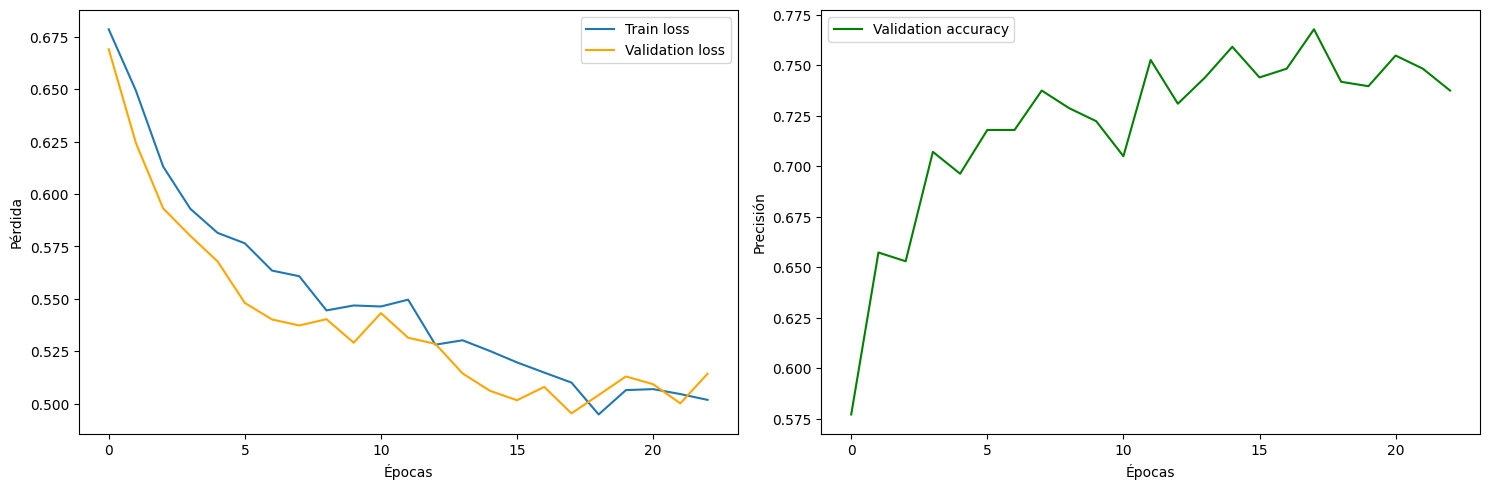

TESTnro2 MODELO FINAL DROPOUT 40% Precisión final en test: 80%

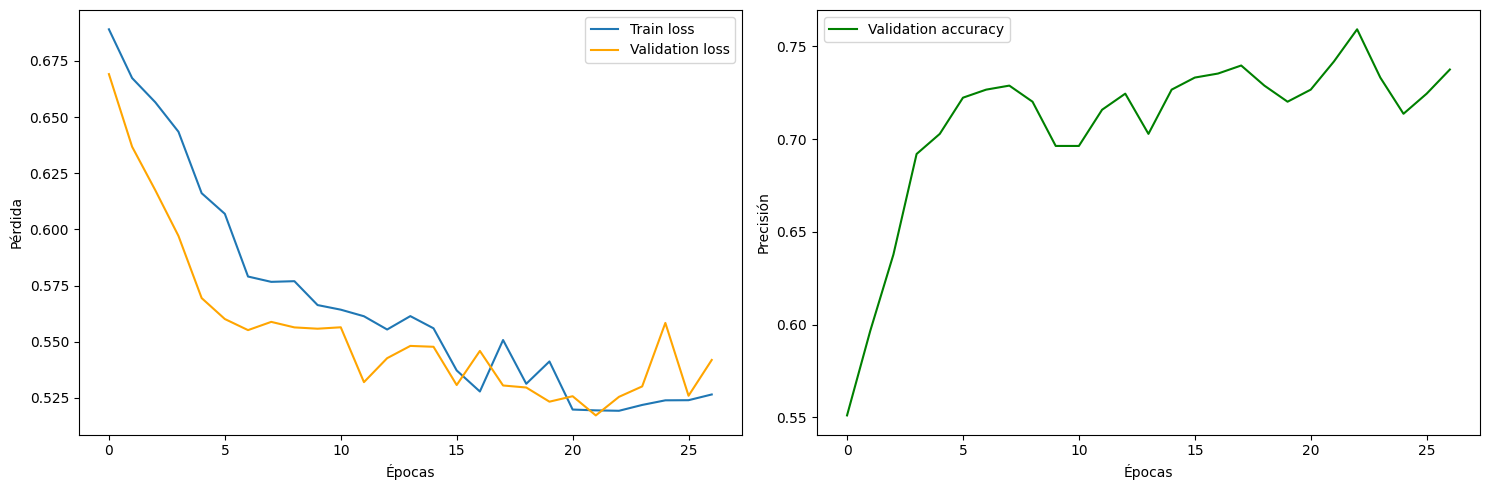



AUMENTAMOS UNA CAPA PARA SUAVIZAR LA TRANSICION DE LA ULTIMA CAPA OCULTA A LA CAPA DE SALIDA

BATCH=512 Precisión final en test: 74%

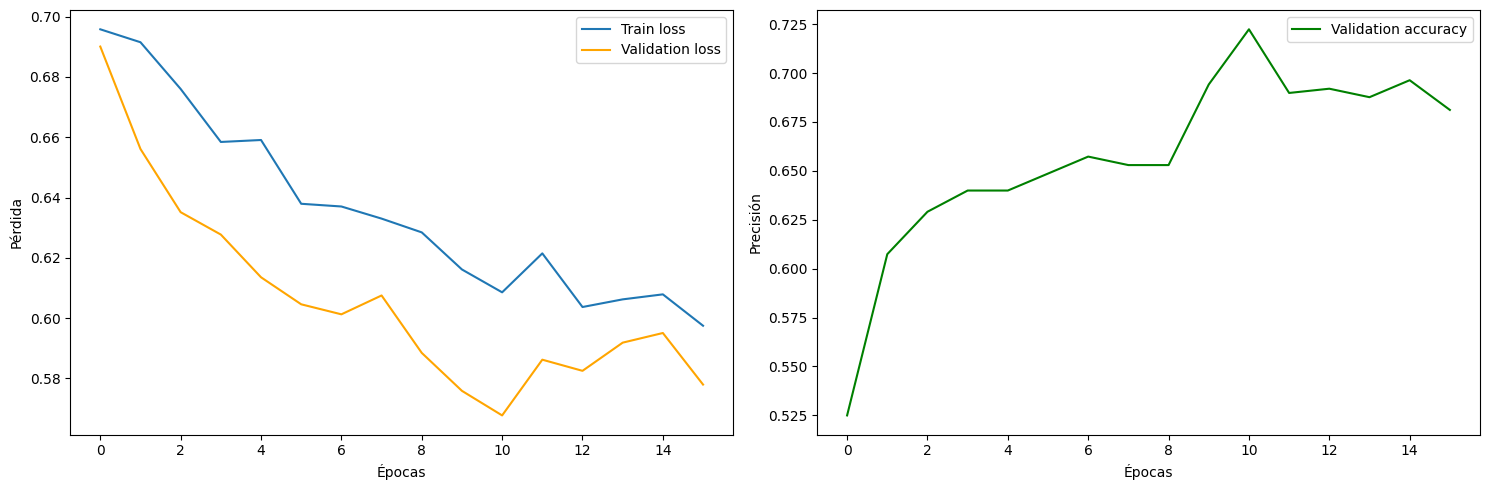

GUARDADO DEL MEJOR MODELO HASTA EL MOMENTO

In [ ]:
model_path = '/content/drive/MyDrive/ClassifierFinal.pth'
torch.save(model.state_dict(), model_path)

print(f"Modelo guardado en {model_path}")


Modelo guardado en /content/drive/MyDrive/ClassifierFinal.pth


In [ ]:
model_path = '/content/drive/MyDrive/ClassifierFinal.pth'

model = ClassifierFinal()
model.load_state_dict(torch.load(model_path))
model.eval()


ClassifierFinal(
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

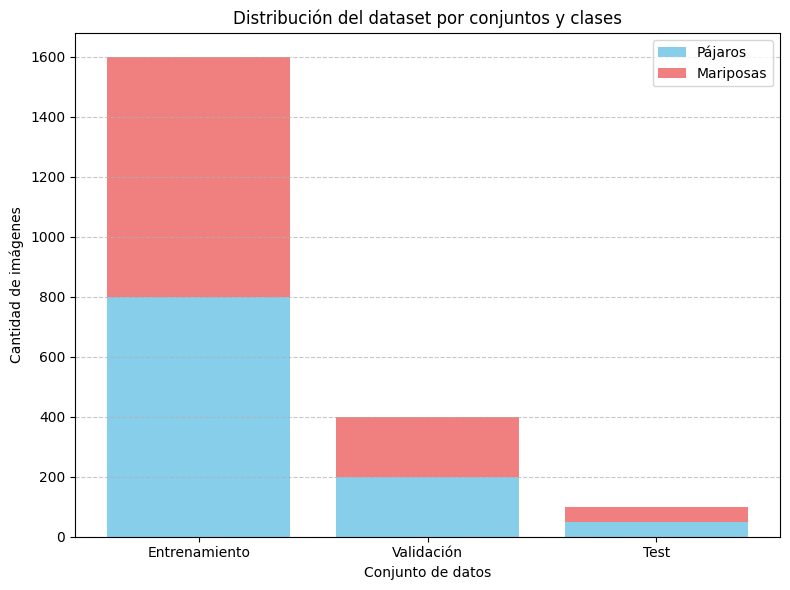

In [ ]:
import matplotlib.pyplot as plt

# Datos
conjuntos = ['Entrenamiento', 'Validación', 'Test']
pajaros = [800, 200, 50]
mariposas = [800, 200, 50]

# Crear gráfico
plt.figure(figsize=(8,6))
plt.bar(conjuntos, pajaros, label='Pájaros', color='skyblue')
plt.bar(conjuntos, mariposas, bottom=pajaros, label='Mariposas', color='lightcoral')

# Etiquetas
plt.title('Distribución del dataset por conjuntos y clases')
plt.xlabel('Conjunto de datos')
plt.ylabel('Cantidad de imágenes')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


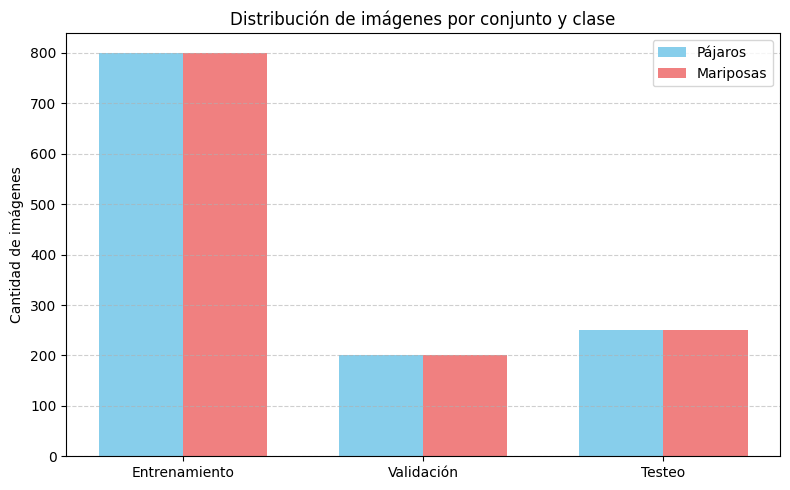

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos actualizados
categorias = ['Entrenamiento', 'Validación', 'Testeo']
pajaros = [800, 200, 250]
mariposas = [800, 200, 250]

x = np.arange(len(categorias))  # posiciones
width = 0.35  # ancho de cada barra

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pajaros, width, label='Pájaros', color='skyblue')
plt.bar(x + width/2, mariposas, width, label='Mariposas', color='lightcoral')

# Estética
plt.ylabel('Cantidad de imágenes')
plt.title('Distribución de imágenes por conjunto y clase')
plt.xticks(x, categorias)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Mostrar
plt.tight_layout()
plt.show()
